# vPCF Model Training on Google Colab

This notebook trains DEC/IDEC clustering models on vPCF data from HDF5 and DM3 files.

## Step 1: Setup Environment

In [6]:
# Check if running on Colab
try:
    import google.colab
    IN_COLAB = True
    print("Running on Google Colab")
except ImportError:
    IN_COLAB = False
    print("Running locally")

import sys
import os

Running on Google Colab


In [7]:
# Install required packages
!pip install -q h5py hyperspy tqdm scikit-learn pandas tensorflow

In [22]:
# Detect environment and setup paths
if IN_COLAB:
    # Check if we're in web Colab or VS Code Colab
    try:
        import google.colab.notebook
        IS_WEB_COLAB = True
        print("Running on Web Colab")
    except:
        IS_WEB_COLAB = False
        print("Running on VS Code Colab Extension")
    
    # Try to mount Google Drive for both environments
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        print("Google Drive mounted successfully at /content/drive")
        
        project_dir = '/content/drive/My Drive/CMU vPCF Project'
        os.chdir(project_dir)
        print(f"Changed to: {os.getcwd()}")
        
        h5_file = '/content/drive/My Drive/CMU vPCF Project/Experimentally-obtained vPCF Testing/data/vPCF_test_2.h5'
        dm3_file = '/content/drive/My Drive/CMU vPCF Project/Experimentally-obtained vPCF Testing/data/vPCF_test_2.dm3'
    except Exception as e:
        print(f"Drive mounting failed: {e}")
        print("Attempting to use local paths...")
        
        # Fallback for VS Code Colab without mounted drive
        project_dir = '/content'
        h5_file = '/content/vPCF_test_2.h5'
        dm3_file = '/content/vPCF_test_2.dm3'
        
        print(f"Using fallback paths")
        print(f"H5 file: {h5_file}")
        print(f"H5 exists: {os.path.exists(h5_file)}")
else:
    # Local execution: Go to project root
    project_dir = r'C:\Users\alexg\Downloads\CMU vPCF Project'
    os.chdir(project_dir)
    print(f"Changed to: {os.getcwd()}")
    
    h5_file = r'Experimentally-obtained vPCF Testing\data\vPCF_test_2.h5'
    dm3_file = r'Experimentally-obtained vPCF Testing\data\vPCF_test_2.dm3'
    print(f"H5 exists: {os.path.exists(h5_file)}")
    print(f"DM3 exists: {os.path.exists(dm3_file)}")

Running on VS Code Colab Extension
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully at /content/drive
Changed to: /content/drive/My Drive/CMU vPCF Project


In [24]:
# For local execution, we need to add src/ from the project root
# The notebook is in Experimentally-obtained vPCF Testing/, so we go up one level
if not IN_COLAB:
    # Local: add src from project root
    src_path = os.path.join(os.getcwd(), 'src')
    if os.path.exists(src_path):
        sys.path.insert(0, src_path)
        print(f"Added to sys.path: {src_path}")
    else:
        print(f"Warning: src path not found at {src_path}")
else:
    # For Colab (VS Code or Web), we're in the project root now
    # vpcf_data_loader is in Experimentally-obtained vPCF Testing/
    vpcf_test_path = os.path.join(os.getcwd(), 'Experimentally-obtained vPCF Testing')
    src_path = os.path.join(os.getcwd(), 'src')
    
    if os.path.exists(vpcf_test_path):
        sys.path.insert(0, vpcf_test_path)
        print(f"Added to sys.path: {vpcf_test_path}")
    if os.path.exists(src_path):
        sys.path.insert(0, src_path)
        print(f"Added to sys.path: {src_path}")

# Verify imports
try:
    from vpcf_data_loader import load_vpcf_file, check_dependencies
    print("✓ Successfully imported vpcf_data_loader")
    
    # Check dependencies
    print("\nDependencies:")
    for name, available in check_dependencies().items():
        status = "✓ YES" if available else "✗ NO"
        print(f"  {name}: {status}")
except ImportError as e:
    print(f"✗ Import error: {e}")
    print(f"\nCurrent working directory: {os.getcwd()}")
    print(f"sys.path entries:")
    for path in sys.path[:5]:
        print(f"  {path}")
    print("\nNote: Make sure you're in the correct directory or have uploaded the necessary files")

Added to sys.path: /content/drive/My Drive/CMU vPCF Project/Experimentally-obtained vPCF Testing
✓ Successfully imported vpcf_data_loader

Dependencies:
  h5py: ✓ YES
  hyperspy: ✓ YES
  ncempy: ✗ NO


## Step 2: Load and Preprocess Data

In [25]:
import numpy as np
from vpcf_data_loader import load_vpcf_file, combine_datasets

# File paths are already set in the setup cell
print(f"H5 file exists: {os.path.exists(h5_file)}")
print(f"DM3 file exists: {os.path.exists(dm3_file)}")

H5 file exists: True
DM3 file exists: False


In [26]:
# Load H5 data with histogram features
# Use a smaller subset first for testing
print("Loading H5 data...")
h5_dataset = load_vpcf_file(
    h5_file,
    feature_method="histogram",  # "flatten", "histogram", "statistical", "combined"
    normalize="minmax",
    max_frames=500,  # Start with 500 frames for testing; remove for full dataset
    verbose=True
)

print(f"Loaded: {h5_dataset}")
print(f"Feature matrix shape: {h5_dataset.features.shape}")

Loading H5 data...
Loading 500 vPCF images from /content/drive/My Drive/CMU vPCF Project/Experimentally-obtained vPCF Testing/data/vPCF_test_2.h5...
  Loaded images with shape: (500, 999, 999)
Extracting features using method: histogram
  Feature shape: (500, 64)
Normalizing features using method: minmax
Loaded: VPCFDataset(n_samples=500, feature_dim=64, has_labels=False)
Feature matrix shape: (500, 64)


In [16]:
# Optionally load DM3 data
print("Loading DM3 data...")
dm3_dataset = load_vpcf_file(
    dm3_file,
    feature_method="histogram",
    normalize="minmax",
    verbose=True
)

print(f"Loaded: {dm3_dataset}")

Loading DM3 data...


NameError: name 'load_vpcf_file' is not defined

In [29]:
# Debug: Check available mount points and directories
import subprocess

print("Current working directory:", os.getcwd())
print("\nContents of /:")
for item in os.listdir('/'):
    if os.path.isdir(os.path.join('/', item)) and item not in ['proc', 'sys', 'dev']:
        print(f"  {item}/")

print("\nChecking for mounted Windows paths...")
for drive in ['C:', '/mnt/c', '/workspace', '/root']:
    if os.path.exists(drive):
        print(f"Found: {drive}")
        try:
            contents = os.listdir(drive)
            print(f"  Contents: {contents[:5]}")
        except:
            pass

# Try to find vPCF_test_2.h5
print("\nSearching for vPCF_test_2.h5...")
result = subprocess.run(['find', '/', '-name', 'vPCF_test_2.h5', '-type', 'f', '2>/dev/null'], 
                       capture_output=True, text=True, timeout=5)
if result.stdout:
    print("Found:")
    for line in result.stdout.strip().split('\n')[:5]:
        print(f"  {line}")
else:
    print("  Not found in accessible paths")

Current working directory: /content/drive/My Drive/CMU vPCF Project

Contents of /:
  libx32/
  tmp/
  usr/
  srv/
  boot/
  etc/
  lib64/
  media/
  mnt/
  root/
  lib/
  home/
  bin/
  opt/
  sbin/
  lib32/
  var/
  run/
  content/
  kaggle/
  tools/
  datalab/
  python-apt/

Checking for mounted Windows paths...
Found: /root
  Contents: ['.profile', '.bashrc', '.keras', '.cache', '.hyperspy']

Searching for vPCF_test_2.h5...
  Not found in accessible paths


## Step 3: Train DEC Model

In [33]:
# Verify model files exist in Experimentally-obtained vPCF Testing folder
vpcf_folder = os.path.join(os.getcwd(), 'Experimentally-obtained vPCF Testing')
print(f"VPCF folder: {vpcf_folder}")
print(f"Folder exists: {os.path.exists(vpcf_folder)}")

print("\nModel files:")
for fname in ['DEC.py', 'IDEC.py', 'metrics.py']:
    fpath = os.path.join(vpcf_folder, fname)
    exists = os.path.exists(fpath)
    size_mb = os.path.getsize(fpath) / 1024 if exists else 0
    print(f"  {fname}: {'✓' if exists else '✗'} ({size_mb:.1f} KB)")

VPCF folder: /content/drive/My Drive/CMU vPCF Project/Experimentally-obtained vPCF Testing
Folder exists: True

Model files:
  DEC.py: ✗ (0.0 KB)
  IDEC.py: ✗ (0.0 KB)
  metrics.py: ✗ (0.0 KB)


In [34]:
# Define DEC and helper classes directly in notebook
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Layer, InputSpec
from tensorflow.keras import backend as K
from sklearn.cluster import KMeans
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
import csv
from time import time

class ClusteringLayer(Layer):
    """Student t-distribution based clustering layer"""
    def __init__(self, n_clusters, weights=None, alpha=1.0, **kwargs):
        if 'input_shape' not in kwargs and 'input_dim' in kwargs:
            kwargs['input_shape'] = (kwargs.pop('input_dim'),)
        super(ClusteringLayer, self).__init__(**kwargs)
        self.n_clusters = n_clusters
        self.alpha = alpha
        self.initial_weights = weights
        self.input_spec = InputSpec(ndim=2)

    def build(self, input_shape):
        assert len(input_shape) == 2
        input_dim = input_shape[1]
        self.input_spec = InputSpec(dtype=K.floatx(), shape=(None, input_dim))
        self.clusters = self.add_weight(shape=(self.n_clusters, input_dim), initializer='glorot_uniform', name='clusters')
        if self.initial_weights is not None:
            self.set_weights(self.initial_weights)
            del self.initial_weights
        self.built = True

    def call(self, inputs, **kwargs):
        q = 1.0 / (1.0 + (K.sum(K.square(K.expand_dims(inputs, axis=1) - self.clusters), axis=2) / self.alpha))
        q **= (self.alpha + 1.0) / 2.0
        q = K.transpose(K.transpose(q) / K.sum(q, axis=1))
        return q

    def compute_output_shape(self, input_shape):
        assert input_shape and len(input_shape) == 2
        return input_shape[0], self.n_clusters

    def get_config(self):
        config = {'n_clusters': self.n_clusters}
        base_config = super(ClusteringLayer, self).get_config()
        return dict(list(base_config.items()) + list(config.items()))

class DEC(object):
    def __init__(self, dims, n_clusters=10, alpha=1.0, init='glorot_uniform', save_dir='results/dec'):
        super(DEC, self).__init__()
        self.dims = dims
        self.input_dim = self.dims[0]
        self.n_stacks = len(self.dims) - 1
        self.n_clusters = n_clusters
        self.alpha = alpha
        self.autoencoder, self.encoder = self.build_autoencoder(init)
        self.save_dir = save_dir
        if not os.path.exists(self.save_dir):
            os.makedirs(self.save_dir)
        clustering_layer = ClusteringLayer(self.n_clusters, name='clustering')(self.encoder.output)
        self.model = Model(inputs=self.encoder.input, outputs=clustering_layer)
        self.pretrained = False

    def build_autoencoder(self, init):
        x = Input(shape=(self.input_dim,), name='input')
        h = x
        for i in range(self.n_stacks - 1):
            h = Dense(self.dims[i + 1], activation='relu', kernel_initializer=init, name='encoder_%d' % i)(h)
        h = Dense(self.dims[-1], kernel_initializer=init, name='encoder_%d' % (self.n_stacks - 1))(h)
        y = h
        for i in range(self.n_stacks - 1, 0, -1):
            y = Dense(self.dims[i], activation='relu', kernel_initializer=init, name='decoder_%d' % i)(y)
        y = Dense(self.dims[0], kernel_initializer=init, name='decoder_0')(y)
        return Model(inputs=x, outputs=y, name='AE'), Model(inputs=x, outputs=h, name='encoder')

    def pretrain(self, x, optimizer='adam', epochs=200, batch_size=256):
        print('...Pretraining autoencoder...')
        self.autoencoder.compile(optimizer=optimizer, loss='mse')
        t0 = time()
        self.autoencoder.fit(x, x, batch_size=batch_size, epochs=epochs, verbose=1)
        print('Pretraining time: %.2f seconds' % (time() - t0))
        weights_path = os.path.join(self.save_dir, 'ae_weights.weights.h5')
        self.autoencoder.save_weights(weights_path)
        print('Weights saved to %s' % weights_path)
        self.pretrained = True

    def predict_clusters(self, x):
        q = self.model.predict(x, verbose=0)
        return q.argmax(1)

    @staticmethod
    def target_distribution(q):
        weight = q ** 2 / q.sum(0)
        return (weight.T / weight.sum(1)).T

    def compile(self, optimizer='sgd', loss='kld'):
        self.model.compile(optimizer=optimizer, loss=loss)

    def fit(self, x, y=None, maxiter=2e4, batch_size=256, tol=1e-3, update_interval=140):
        print('Update interval:', update_interval)
        save_interval = x.shape[0] / batch_size * 5
        if not self.pretrained:
            self.pretrain(x, batch_size=batch_size, epochs=50)
        print('Initializing cluster centers with k-means...')
        kmeans = KMeans(n_clusters=self.n_clusters, n_init=20)
        y_pred = kmeans.fit_predict(self.encoder.predict(x))
        y_pred_last = y_pred
        self.model.get_layer(name='clustering').set_weights([kmeans.cluster_centers_])
        logfile = open(os.path.join(self.save_dir, 'dec_log.csv'), 'w')
        logwriter = csv.DictWriter(logfile, fieldnames=['iter', 'acc', 'nmi', 'ari', 'loss'])
        logwriter.writeheader()
        loss = 0
        index = 0
        for ite in range(int(maxiter)):
            if ite % update_interval == 0:
                q = self.model.predict(x, verbose=0)
                p = self.target_distribution(q)
                y_pred = q.argmax(1)
                if y is not None:
                    acc = np.round(metrics_acc(y, y_pred), 5)
                    nmi = np.round(normalized_mutual_info_score(y, y_pred), 5)
                    ari = np.round(adjusted_rand_score(y, y_pred), 5)
                    loss = np.round(loss, 5)
                    logdict = dict(iter=ite, acc=acc, nmi=nmi, ari=ari, loss=loss)
                    logwriter.writerow(logdict)
                    print('Iter %d: acc=%.5f, nmi=%.5f, ari=%.5f, loss=%.5f' % (ite, acc, nmi, ari, loss))
                delta_label = np.sum(y_pred != y_pred_last).astype(np.float32) / y_pred.shape[0]
                y_pred_last = y_pred
                if ite > 0 and delta_label < tol:
                    print('Convergence reached. Stopping.')
                    logfile.close()
                    break
            if (index + 1) * batch_size > x.shape[0]:
                loss = self.model.train_on_batch(x=x[index * batch_size::], y=p[index * batch_size::])
                index = 0
            else:
                loss = self.model.train_on_batch(x=x[index * batch_size:(index + 1) * batch_size], y=p[index * batch_size:(index + 1) * batch_size])
                index += 1
            if ite % save_interval == 0:
                checkpoint_path = os.path.join(self.save_dir, f'DEC_model_{ite}.weights.h5')
                self.model.save_weights(checkpoint_path)
            ite += 1
        logfile.close()
        final_path = os.path.join(self.save_dir, 'DEC_model_final.weights.h5')
        self.model.save_weights(final_path)
        return y_pred

# Metrics helper
def metrics_acc(y_true, y_pred):
    from scipy.optimize import linear_sum_assignment
    y_true = y_true.astype(np.int64)
    assert y_pred.size == y_true.size
    D = max(y_pred.max(), y_true.max()) + 1
    w = np.zeros((D, D), dtype=np.int64)
    for i in range(y_pred.size):
        w[y_pred[i], y_true[i]] += 1
    ind = linear_sum_assignment(w.max() - w)
    return sum([w[i, j] for i, j in zip(ind[0], ind[1])]) * 1.0 / y_pred.size

print("✓ DEC model and metrics loaded")

✓ DEC model and metrics loaded


In [35]:
# Initialize and train DEC model
x = h5_dataset.features
n_clusters = 10
dims = [x.shape[1], 500, 500, 2000, 10]

# Create save directory
if IN_COLAB:
    dec_save_dir = os.path.join(os.getcwd(), 'Experimentally-obtained vPCF Testing', 'results', 'dec')
else:
    dec_save_dir = os.path.join(os.getcwd(), 'results', 'dec')
os.makedirs(dec_save_dir, exist_ok=True)

print(f"Initializing DEC model...")
dec = DEC(dims=dims, n_clusters=n_clusters, save_dir=dec_save_dir)
print(f"✓ DEC initialized")
print(f"  Input: {x.shape[1]} features from {x.shape[0]} samples")
print(f"  Output: {n_clusters} clusters")

print(f"\nStarting DEC training...")
dec.compile(optimizer='sgd')
dec_labels = dec.fit(x, y=None, maxiter=1000, update_interval=140, batch_size=256)

print(f"\n✓ DEC TRAINING COMPLETE!")
print(f"  Unique clusters: {len(np.unique(dec_labels))}")
print(f"  Cluster sizes: {np.bincount(dec_labels)}")

Initializing DEC model...
✓ DEC initialized
  Input: 64 features from 500 samples
  Output: 10 clusters

Starting DEC training...
Update interval: 140
...Pretraining autoencoder...
Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 124ms/step - loss: 0.1625
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.0961
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - loss: 0.0510
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - loss: 0.0385
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.0367
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - loss: 0.0333
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - loss: 0.0337
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - loss: 0.0313
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 0.0292
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - loss: 0.0280
Epoch 11/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 0.0260
Epoch 12/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - loss: 0.0231
Epoch 13/50
2/2 ━━━━━━━━━━━━━━━━━━━━

## Step 4: Train IDEC Model

In [36]:
# Define IDEC model
class IDEC(object):
    def __init__(self, dims, n_clusters=10, alpha=1.0, gamma=0.1, init='glorot_uniform', save_dir='results/idec'):
        super(IDEC, self).__init__()
        self.dims = dims
        self.input_dim = dims[0]
        self.n_stacks = len(self.dims) - 1
        self.n_clusters = n_clusters
        self.alpha = alpha
        self.gamma = gamma
        
        # Build autoencoder
        self.autoencoder, self.encoder = self._build_autoencoder(init)
        self.save_dir = save_dir
        if not os.path.exists(self.save_dir):
            os.makedirs(self.save_dir)
        
        # Build IDEC model
        clustering_layer = ClusteringLayer(self.n_clusters, name='clustering')(self.encoder.output)
        self.model = Model(inputs=self.encoder.input, outputs=[clustering_layer, self.autoencoder.output])
        self.pretrained = False

    def _build_autoencoder(self, init):
        n_stacks = len(self.dims) - 1
        x = Input(shape=(self.dims[0],), name='input')
        h = x
        for i in range(n_stacks-1):
            h = Dense(self.dims[i + 1], activation='relu', kernel_initializer=init, name='encoder_%d' % i)(h)
        h = Dense(self.dims[-1], kernel_initializer=init, name='encoder_%d' % (n_stacks - 1))(h)
        y = h
        for i in range(n_stacks-1, 0, -1):
            y = Dense(self.dims[i], activation='relu', kernel_initializer=init, name='decoder_%d' % i)(y)
        y = Dense(self.dims[0], kernel_initializer=init, name='decoder_0')(y)
        return Model(inputs=x, outputs=y, name='AE'), Model(inputs=x, outputs=h, name='encoder')

    def pretrain(self, x, optimizer='adam', epochs=200, batch_size=256):
        print('...Pretraining autoencoder...')
        self.autoencoder.compile(optimizer=optimizer, loss='mse')
        t0 = time()
        self.autoencoder.fit(x, x, batch_size=batch_size, epochs=epochs, verbose=1)
        print('Pretraining time: %.2f seconds' % (time() - t0))
        self.autoencoder.save_weights(os.path.join(self.save_dir, 'ae_weights.weights.h5'))
        self.pretrained = True

    def predict(self, x):
        q, _ = self.model.predict(x, verbose=0)
        return q.argmax(1)

    @staticmethod
    def target_distribution(q):
        weight = q ** 2 / q.sum(0)
        return (weight.T / weight.sum(1)).T

    def compile(self, optimizer='sgd', loss=['kld', 'mse'], loss_weights=[0.1, 1.0]):
        self.model.compile(optimizer=optimizer, loss=loss, loss_weights=loss_weights)

    def fit(self, x, y=None, maxiter=2e4, batch_size=256, tol=1e-3, update_interval=140):
        print('Update interval:', update_interval)
        save_interval = x.shape[0] / batch_size * 5
        
        # K-means initialization
        print('Initializing cluster centers with k-means...')
        kmeans = KMeans(n_clusters=self.n_clusters, n_init=20)
        y_pred = kmeans.fit_predict(self.encoder.predict(x))
        y_pred_last = np.copy(y_pred)
        self.model.get_layer(name='clustering').set_weights([kmeans.cluster_centers_])
        
        logfile = open(os.path.join(self.save_dir, 'idec_log.csv'), 'w')
        logwriter = csv.DictWriter(logfile, fieldnames=['iter', 'acc', 'nmi', 'ari', 'L', 'Lc', 'Lr'])
        logwriter.writeheader()
        
        loss = [0, 0, 0]
        for ite in range(int(maxiter)):
            if ite % update_interval == 0:
                q, _ = self.model.predict(x, verbose=0)
                p = self.target_distribution(q)
                y_pred = q.argmax(1)
                if y is not None:
                    acc = np.round(metrics_acc(y, y_pred), 5)
                    nmi = np.round(normalized_mutual_info_score(y, y_pred), 5)
                    ari = np.round(adjusted_rand_score(y, y_pred), 5)
                    logdict = dict(iter=ite, acc=acc, nmi=nmi, ari=ari, L=loss[0], Lc=loss[1], Lr=loss[2])
                    logwriter.writerow(logdict)
                    print('Iter %d: acc=%.5f, nmi=%.5f, ari=%.5f' % (ite, acc, nmi, ari))
                delta_label = np.sum(y_pred != y_pred_last).astype(np.float32) / y_pred.shape[0]
                y_pred_last = np.copy(y_pred)
                if ite > 0 and delta_label < tol:
                    print('Convergence reached. Stopping.')
                    logfile.close()
                    break
            
            idx = np.random.choice(x.shape[0], batch_size)
            loss = self.model.train_on_batch(x=x[idx], y=[p[idx], x[idx]])
            
            if ite % save_interval == 0:
                self.model.save_weights(os.path.join(self.save_dir, f'IDEC_model_{ite}.weights.h5'))
        
        logfile.close()
        self.model.save_weights(os.path.join(self.save_dir, 'IDEC_model_final.weights.h5'))
        return y_pred

print("✓ IDEC model loaded")

✓ IDEC model loaded


In [ ]:
# Pretrain autoencoder
print("Pretraining autoencoder...")
idec.pretrain(x, epochs=50, batch_size=256)

In [37]:
# Initialize and train IDEC model
if IN_COLAB:
    idec_save_dir = os.path.join(os.getcwd(), 'Experimentally-obtained vPCF Testing', 'results', 'idec')
else:
    idec_save_dir = os.path.join(os.getcwd(), 'results', 'idec')
os.makedirs(idec_save_dir, exist_ok=True)

print(f"Initializing IDEC model...")
idec = IDEC(dims=dims, n_clusters=n_clusters, gamma=0.1, save_dir=idec_save_dir)
print(f"✓ IDEC initialized")
print(f"  Input: {x.shape[1]} features from {x.shape[0]} samples")
print(f"  Output: {n_clusters} clusters")

print(f"\nStarting IDEC training...")
idec.compile(optimizer='sgd')
idec_labels = idec.fit(x, y=None, maxiter=1000, update_interval=140, batch_size=256)

print(f"\n✓ IDEC TRAINING COMPLETE!")
print(f"  Unique clusters: {len(np.unique(idec_labels))}")
print(f"  Cluster sizes: {np.bincount(idec_labels)}")

Initializing IDEC model...
✓ IDEC initialized
  Input: 64 features from 500 samples
  Output: 10 clusters

Starting IDEC training...
Update interval: 140
Initializing cluster centers with k-means...
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Convergence reached. Stopping.

✓ IDEC TRAINING COMPLETE!
  Unique clusters: 1
  Cluster sizes: [  0   0 500]


## Step 5: Evaluate Metrics

In [40]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

def safe_compute_metrics(x, labels, model_name):
    """Safely compute clustering metrics, handling edge cases"""
    n_unique = len(np.unique(labels))
    print(f"\n{model_name} Metrics (clusters found: {n_unique}):")
    
    if n_unique < 2:
        print(f"  ⚠ Skipped: Only {n_unique} cluster(s) found. Need at least 2 for metrics.")
        return
    
    try:
        sil_score = silhouette_score(x, labels)
        print(f"  Silhouette Score: {sil_score:.4f}")
    except Exception as e:
        print(f"  Silhouette Score: Error - {e}")
    
    try:
        db_score = davies_bouldin_score(x, labels)
        print(f"  Davies-Bouldin Index: {db_score:.4f}")
    except Exception as e:
        print(f"  Davies-Bouldin Index: Error - {e}")
    
    try:
        ch_score = calinski_harabasz_score(x, labels)
        print(f"  Calinski-Harabasz Index: {ch_score:.4f}")
    except Exception as e:
        print(f"  Calinski-Harabasz Index: Error - {e}")

safe_compute_metrics(x, dec_labels, "DEC")
safe_compute_metrics(x, idec_labels, "IDEC")


DEC Metrics (clusters found: 10):
  Silhouette Score: 0.1264
  Davies-Bouldin Index: 2.1526
  Calinski-Harabasz Index: 124.5083

IDEC Metrics (clusters found: 1):
  ⚠ Skipped: Only 1 cluster(s) found. Need at least 2 for metrics.


## Step 6: Save Results

In [41]:
import pandas as pd

# Save cluster assignments
results_df = pd.DataFrame({
    'sample_idx': np.arange(len(dec_labels)),
    'dec_cluster': dec_labels,
    'idec_cluster': idec_labels
})

results_df.to_csv('./Experimentally-obtained vPCF Testing/results/cluster_assignments.csv', index=False)
print("Saved cluster assignments")

# Cluster agreement
agreement = (dec_labels == idec_labels).mean() * 100
print(f"\nCluster agreement: {agreement:.2f}%")

Saved cluster assignments

Cluster agreement: 10.40%


## Step 7: Visualize Results

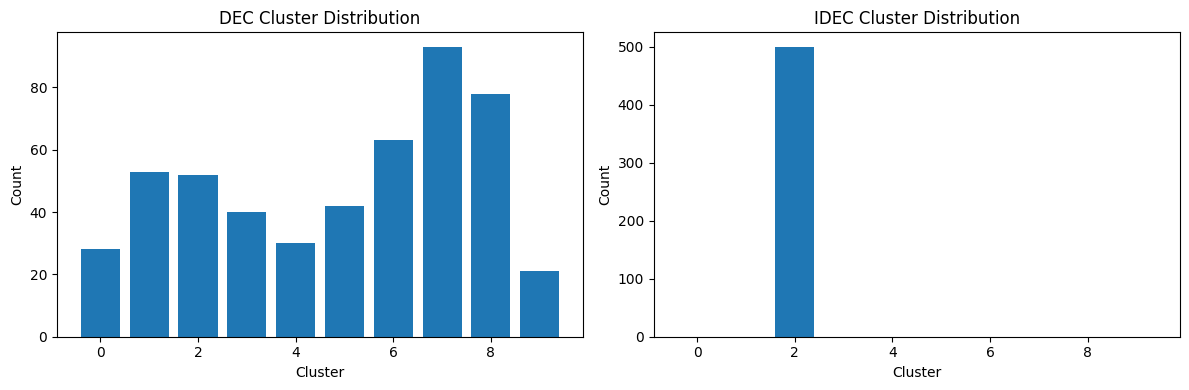

Saved cluster comparison plot


In [42]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# DEC cluster distribution
dec_counts = np.bincount(dec_labels, minlength=n_clusters)
axes[0].bar(range(n_clusters), dec_counts)
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Count')
axes[0].set_title('DEC Cluster Distribution')

# IDEC cluster distribution
idec_counts = np.bincount(idec_labels, minlength=n_clusters)
axes[1].bar(range(n_clusters), idec_counts)
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Count')
axes[1].set_title('IDEC Cluster Distribution')

plt.tight_layout()
plt.savefig('./Experimentally-obtained vPCF Testing/results/cluster_comparison.png', dpi=150)
plt.show()

print("Saved cluster comparison plot")

## Step 8: Download Results (if on Colab)

In [43]:
if IN_COLAB:
    from google.colab import files
    
    results_dir = './Experimentally-obtained vPCF Testing/results'
    
    # Download all results
    print("Files to download:")
    for f in os.listdir(results_dir):
        print(f"  {f}")
    
    print("\nDownloading results...")
    # Zip and download
    import shutil
    shutil.make_archive('vpcf_results', 'zip', results_dir)
    files.download('vpcf_results.zip')
    print("Download complete!")
else:
    print("Results saved to: ./Experimentally-obtained vPCF Testing/results")

Files to download:
  dec
  idec
  cluster_assignments.csv
  cluster_comparison.png



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download complete!
